In [130]:
from IPython.display import IFrame
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, Legend, BoxSelectTool, HoverTool
from bokeh.layouts import gridplot, column, row

output_notebook()

Loading BokehJS ...

## TOC

What this notebook covers:
- shapefiles, geojson, and geopandas
- geospatial-visualizations in bokeh and folium
- choropleth, heatmap, and heatmap with time

## Shapefiles and geojson

The two most used format to distribute geospatial data are shapefile and GeoJSON. Shapefile is a standard defined by Esri almost 30 years ago, whereas geojson was introduced about 10 years ago by a community of GIS (Geographic Information System) developers.

Shapefile is actually not a single file, but a collection of files and, internally, it uses a binary format for encoding the geometries (WKB). In the shapefile representation, 3 files are required:

1. the `.shp` file, which contains the feature geometry
2. the `.shx` file, which is the index of the feature geometry
3. the `.dbf` file, which provides properties attached to the various shapes (like name, id, etc.)

GeoJSON is a subset of JSON which was created to provide a specification for encoding geospatial data while remaining decodable by any JSON decoder, so web-friendly.

In [131]:
IFrame(src='https://en.wikipedia.org/wiki/Shapefile', width=800, height=600)

## Geopandas

Python and jupyter supports geospatial data with a number of libraries. One of particular interest is GeoPandas, which extends Pandas dataframes to enable spatial operations on geometric types. These operations are in turn performed behind the scene by another library called `shapely`, which is a Python package to manipulate and analyze planar geometric objects.

GeoPandas supports reading and writing shapefiles and geojson out of the box.

Let's look at a couple of examples. In the first one we load a geojson which includes boroughs of NYC.

In [132]:
import geopandas as gpd

gpd.read_file("./Datasets/nyc-boroughs.geojson")

,boroughCode,borough,@id,geometry
0,5,Staten Island,http://nyc.pediacities.com/Resource/Borough/St...,"POLYGON ((-74.05051 40.56642, -74.04998 40.566..."
1,5,Staten Island,http://nyc.pediacities.com/Resource/Borough/St...,"POLYGON ((-74.05314 40.5777, -74.05406 40.5771..."
2,5,Staten Island,http://nyc.pediacities.com/Resource/Borough/St...,"POLYGON ((-74.15946 40.64145, -74.15998 40.641..."
3,5,Staten Island,http://nyc.pediacities.com/Resource/Borough/St...,"POLYGON ((-74.08221 40.64828, -74.08142 40.648..."
4,4,Queens,http://nyc.pediacities.com/Resource/Borough/Qu...,"POLYGON ((-73.83668 40.59495, -73.83671 40.594..."
...,...,...,...,...
99,2,Bronx,http://nyc.pediacities.com/Resource/Borough/Bronx,"POLYGON ((-73.78103 40.87648, -73.78121 40.876..."
100,2,Bronx,http://nyc.pediacities.com/Resource/Borough/Bronx,"POLYGON ((-73.78651 40.88094, -73.78582 40.880..."
101,2,Bronx,http://nyc.pediacities.com/Resource/Borough/Bronx,"POLYGON ((-73.87295 40.90444, -73.85947 40.900..."
102,2,Bronx,http://nyc.pediacities.com/Resource/Borough/Bronx,"POLYGON ((-73.80518 40.81527, -73.80508 40.815..."


In the second example we use the shapefile of the districts of Lugano, which can be found on the website of  [Statistica Urbana città di Lugano](https://statistica.lugano.ch/site/ogd-demografia/)

In [133]:
IFrame(src='https://statistica.lugano.ch/site/ogd-demografia/', width=800, height=600)

In [134]:
districts = gpd.read_file("./Datasets/shapeFilesQuartieri/quartieri.shp")
districts

,OBJECTID,QUART_ID,NomeQuarti,Shape_Leng,Shape_Area,geometry
0,1,1,Aldesago,3603.794516,3.032742e+05,"POLYGON ((719605.608 97032.549, 719616.018 969..."
1,2,2,Besso,3935.589985,6.466013e+05,"POLYGON ((716238.081 96434.664, 716243.957 964..."
2,3,3,Brè,9230.906731,3.895095e+06,"POLYGON ((721585.079 98659.683, 721643.11 9853..."
3,4,4,Breganzona,7100.286545,2.276976e+06,"POLYGON ((715597.415 97308.572, 715601.931 973..."
4,5,5,Cassarate,3614.404506,4.050159e+05,"POLYGON ((718080.505 96486.76, 718117.419 9648..."
5,6,6,Castagnola,5340.207854,1.015444e+06,"POLYGON ((718704.935 96441.934, 718709.423 964..."
6,7,7,Centro,5834.471905,1.029662e+06,"POLYGON ((717133.371 96838.78, 717133.401 9683..."
7,8,8,Cureggia,4114.676617,6.599055e+05,"POLYGON ((719621.031 98106.056, 719657.892 980..."
8,9,9,Davesco-Soragno,7753.277678,2.498038e+06,"POLYGON ((718954.61 99849.545, 718979.545 9984..."
9,10,10,Gandria,6776.025091,1.313985e+06,"POLYGON ((722243.052 97822.844, 722249.959 978..."


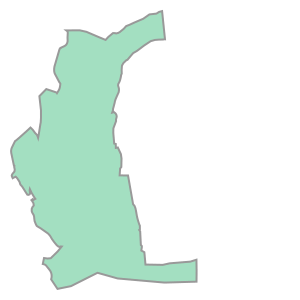

In [135]:
districts.loc[0].geometry

In [136]:
districts2 = districts.set_index("NomeQuarti")

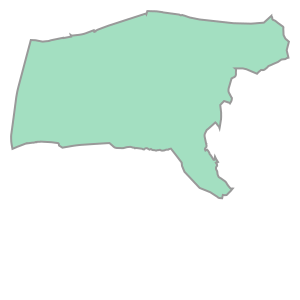

In [137]:
districts2.loc["Viganello"].geometry

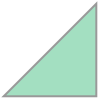

In [138]:
from shapely.geometry import Polygon
polygon = Polygon([(0, 0), (1, 1), (1, 0)])

polygon

In [139]:
districts_json = districts[["geometry", "NomeQuarti"]].to_json()
districts_json[:1000]

'{"type": "FeatureCollection", "features": [{"id": "0", "type": "Feature", "properties": {"NomeQuarti": "Aldesago"}, "geometry": {"type": "Polygon", "coordinates": [[[719605.6079999991, 97032.54890000075], [719616.0179999992, 96931.4290000014], [719613.7899999991, 96931.57699999958], [719609.2410000004, 96930.69189999998], [719602.0910999998, 96930.49289999902], [719596.7470000014, 96930.50989999995], [719590.5168999992, 96930.02589999884], [719579.8790999986, 96929.1708999984], [719564.6680999994, 96924.80900000036], [719559.0958999991, 96921.0540000014], [719540.7551000006, 96908.89600000158], [719527.4569000006, 96898.81920000166], [719521.0480000004, 96893.96290000156], [719514.3359999992, 96889.13309999928], [719502.1391000003, 96882.17990000173], [719498.1559999995, 96877.78000000119], [719481.5579999983, 96858.13300000131], [719476.6871000007, 96855.84090000018], [719466.6409000009, 96845.91789999977], [719461.7100000009, 96837.0260999985], [719460.6270999983, 96821.76099999994]

In [140]:
with open('./Datasets/nyc-boroughs.geojson') as f:
    nyc_geojson = json.load(f)
nyc_geojson

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'id': 0,
   'properties': {'boroughCode': 5,
    'borough': 'Staten Island',
    '@id': 'http://nyc.pediacities.com/Resource/Borough/Staten_Island'},
   'geometry': {'type': 'Polygon',
    'coordinates': [[[-74.05050806403247, 40.566422034160816],
      [-74.04998352562575, 40.56639592492827],
      [-74.04931640362088, 40.56588774778044],
      [-74.04923629842045, 40.5653627363681],
      [-74.05002620158643, 40.565318180621134],
      [-74.05090601705089, 40.5660943421306],
      [-74.05067916748614, 40.5663108457364],
      [-74.05107159803778, 40.5667224933978],
      [-74.05050806403247, 40.566422034160816]]]}},
  {'type': 'Feature',
   'id': 1,
   'properties': {'boroughCode': 5,
    'borough': 'Staten Island',
    '@id': 'http://nyc.pediacities.com/Resource/Borough/Staten_Island'},
   'geometry': {'type': 'Polygon',
    'coordinates': [[[-74.05314036821109, 40.577702715545755],
      [-74.05406044939875, 40.5771

## Choropleth map in bokeh

Let's start by rendering the district polygons that we have in the geopandas dataframe (from the shapefile). To work with geospatial data bokeh uses a GeoJSONDataSource, which takes as input geojson data. Thus, in case we have the geospatial data in a geopandas dataframe or in a shapefile, we need to convert it to geojson.

To render the various polygons we use the Patches glyph in bokeh.

In [141]:
from bokeh.models import GeoJSONDataSource


p = figure(title = 'Lugano districts', 
           frame_height = 600 ,
           frame_width = 600, 
           toolbar_location = 'below',
           tools = "pan, box_zoom, reset")

geo_ds = GeoJSONDataSource(geojson=districts_json)
plotted_districts = p.patches('xs','ys', source = geo_ds,
                   line_color = 'black', 
                   line_width = 0.25)

p.add_tools(HoverTool(renderers = [plotted_districts],
                      tooltips = [("District","@NomeQuarti")]))

show(p)

Now that we have the map of the districts, we want to create a choropleth, mapping the number of residents on the color of the district. We can get the residents data from the same website (Statistica Urbana Lugano).

In [142]:
residents = pd.read_json("./Datasets/q_quartieri_4_2019.json")
residents

,Quartiere,Quartierenome,TotaleAbitantiPrev,TotaleAbitantiCurr
0,1,Aldesago,695.0,654.0
1,17,Barbengo,2345.0,2338.0
2,2,Besso,5143.0,5132.0
3,20,Bogno,205.0,215.0
4,3,Brè,428.0,413.0
5,4,Breganzona,5404.0,5352.0
6,21,Cadro,2685.0,2678.0
7,18,Carabbia,632.0,615.0
8,22,Carona,932.0,916.0
9,5,Cassarate,3724.0,3673.0


In [143]:
districts_residents = districts.merge(residents, left_on="QUART_ID", right_on="Quartiere", how="left")
districts_residents

,OBJECTID,QUART_ID,NomeQuarti,Shape_Leng,Shape_Area,geometry,Quartiere,Quartierenome,TotaleAbitantiPrev,TotaleAbitantiCurr
0,1,1,Aldesago,3603.794516,3.032742e+05,"POLYGON ((719605.608 97032.549, 719616.018 969...",1,Aldesago,695.0,654.0
1,2,2,Besso,3935.589985,6.466013e+05,"POLYGON ((716238.081 96434.664, 716243.957 964...",2,Besso,5143.0,5132.0
2,3,3,Brè,9230.906731,3.895095e+06,"POLYGON ((721585.079 98659.683, 721643.11 9853...",3,Brè,428.0,413.0
3,4,4,Breganzona,7100.286545,2.276976e+06,"POLYGON ((715597.415 97308.572, 715601.931 973...",4,Breganzona,5404.0,5352.0
4,5,5,Cassarate,3614.404506,4.050159e+05,"POLYGON ((718080.505 96486.76, 718117.419 9648...",5,Cassarate,3724.0,3673.0
5,6,6,Castagnola,5340.207854,1.015444e+06,"POLYGON ((718704.935 96441.934, 718709.423 964...",6,Castagnola,2453.0,2449.0
6,7,7,Centro,5834.471905,1.029662e+06,"POLYGON ((717133.371 96838.78, 717133.401 9683...",7,Centro,5412.0,5304.0
7,8,8,Cureggia,4114.676617,6.599055e+05,"POLYGON ((719621.031 98106.056, 719657.892 980...",8,Cureggia,183.0,171.0
8,9,9,Davesco-Soragno,7753.277678,2.498038e+06,"POLYGON ((718954.61 99849.545, 718979.545 9984...",9,Davesco-Soragno,1615.0,1598.0
9,10,10,Gandria,6776.025091,1.313985e+06,"POLYGON ((722243.052 97822.844, 722249.959 978...",10,Gandria,279.0,275.0


To map the number of residents on the color in bokeh, we use a LinearColorMapper.

We will also create a ColorBar which acts as legend.

In [144]:
from bokeh.palettes import Reds
from bokeh.models import LinearColorMapper, ColorBar

districts_residents_json = districts_residents[["NomeQuarti", "TotaleAbitantiCurr", "geometry"]].to_json()
geo_ds = GeoJSONDataSource(geojson=districts_residents_json)

palette = Reds[9]
palette = palette[::-1]

max_residents = districts_residents["TotaleAbitantiCurr"].max()
min_residents = districts_residents["TotaleAbitantiCurr"].min()

color_mapper = LinearColorMapper(palette = palette, low = min_residents, high = max_residents)

color_bar = ColorBar(color_mapper = color_mapper, 
                     width = 20, height = 500,
                     label_standoff = 8,
                     location = (0,0))
    
p = figure(title = "Residents per district in Lugano - Choropleth map", 
           height = 600, width = 600, 
           toolbar_location = "below",
           tools = "pan, box_zoom, reset")

p.xgrid.grid_line_color = None
p.ygrid.grid_line_color = None
p.axis.visible = False

plotted_countries = p.patches("xs","ys", source = geo_ds,
                   fill_color = {"field" : "TotaleAbitantiCurr",
                                 "transform" : color_mapper},
                   line_color = "gray", 
                   line_width = 0.25, 
                   fill_alpha = 1)

p.add_tools(HoverTool(renderers = [plotted_countries],
                      tooltips = [("District","@NomeQuarti"),
                               ("Number of residents", "@TotaleAbitantiCurr{0,0}")]))

p.add_layout(color_bar, "right")
show(p)

The color bar like this is not very useful, based on the principles we discussed in class. Let's adjust it my using less values and meaningful subdivision.

In [145]:
print(districts_residents.TotaleAbitantiCurr.min())
print(districts_residents.TotaleAbitantiCurr.max())

80.0
9630.0


In [146]:
from bokeh.palettes import Reds
from bokeh.models import LinearColorMapper, LogColorMapper, ColorBar

districts_residents_json = districts_residents[["NomeQuarti", "TotaleAbitantiCurr", "geometry"]].to_json()
geo_ds = GeoJSONDataSource(geojson=districts_residents_json)

palette = Reds[5]
palette = palette[::-1]

max_residents = 10000
min_residents = 0

color_mapper = LinearColorMapper(palette = palette, low = min_residents, high = max_residents)

color_bar = ColorBar(color_mapper = color_mapper, 
                     width = 20, height = 500,
                     label_standoff = 8,
                     location = (0,0))
    
p = figure(title = "Residents per district in Lugano - Choropleth map", 
           height = 600, width = 600, 
           toolbar_location = "below",
           tools = "pan, box_zoom, reset")

p.xgrid.grid_line_color = None
p.ygrid.grid_line_color = None
p.axis.visible = False

plotted_countries = p.patches("xs","ys", source = geo_ds,
                   fill_color = {"field" : "TotaleAbitantiCurr",
                                 "transform" : color_mapper},
                   line_color = "gray", 
                   line_width = 0.25, 
                   fill_alpha = 1)

p.add_tools(HoverTool(renderers = [plotted_countries],
                      tooltips = [("District","@NomeQuarti"),
                               ("Number of residents", "@TotaleAbitantiCurr")]))

p.add_layout(color_bar, "right")
show(p)

## Geospatial visualization in bokeh

So far we have seen how to render polygons that we imported from a shapefile or a geojson, without using geographical maps and the corresponding coordinates. 

We will now see how to render maps in bokeh, using the mercator projection. Bokeh, as all map libraries, supports different tiles provider, as for example:
- [CartoDB](https://carto.com/location-data-services/basemaps/)
- [Stamen](http://maps.stamen.com/#toner/12/37.7706/-122.3782)


In [147]:
import xyzservices.providers as xyz

# xyz.Stadia.StamenTerrain
# xyz.Stadia.StamenToner
# STAMEN_TONER

p = figure(x_range=(980000, 1000000), y_range=(5750000, 5800000),
           height = 600, width = 750,
           # tools = "pan, box_zoom, reset",
           x_axis_type="mercator", y_axis_type="mercator")

p.add_tile("CartoDB Positron", retina=True)

show(p)

With a geographical map, we can render geocoded data directly on the map. As discussed in class, we cannot use 2D position to map quantitative values, but instead we have to adopt size and color intensity.

To start, let's see how to render a circle at given coordinates, as for example this one in Lugano: 
- lat = 46.003822
- lon = 8.955392

To render at this coordinates on a bokeh map, we first need to convert the coordinates. Then we can simply put a circle glyph at the converted coordinates.

In [148]:
# WGS = World Geodetic System -- 84 is the last version
def wgs84_to_web_mercator_lon(lon):
    k = 6378137
    return lon * (k * np.pi/180.0)

def wgs84_to_web_mercator_lat(lat):
    k = 6378137
    return np.log(np.tan((90 + lat) * np.pi/360.0)) * k


lon = 8.961044
lat = 46.011382


x = wgs84_to_web_mercator_lon(lon)
y = wgs84_to_web_mercator_lat(lat)

p = figure(x_range=(-1000000, 2000000), y_range=(5000000, 5800000),
           height = 600, width = 750, 
           x_axis_type="mercator", y_axis_type="mercator")
p.add_tile("CartoDB Positron")

p.scatter(x=x, y=y, fill_color='orange', size=10)

show(p)

## Visualizing earthquakes on a bokeh map

Now that we know how to visualize geocoded data in a bokeh map, let's create a visualization of earthquakes.

In [149]:
earthquakes = pd.read_csv("./Datasets/earthquakes.csv")
earthquakes

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.2460,145.6160,Earthquake,131.60,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.8630,127.3520,Earthquake,80.00,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.5790,-173.9720,Earthquake,20.00,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.0760,-23.5570,Earthquake,15.00,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.9380,126.4270,Earthquake,15.00,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23407,12/28/2016,08:22:12,38.3917,-118.8941,Earthquake,12.30,1.2,40.0,5.6,ML,...,18.0,42.47,0.120,NaN,0.1898,NN00570710,NN,NN,NN,Reviewed
23408,12/28/2016,09:13:47,38.3777,-118.8957,Earthquake,8.80,2.0,33.0,5.5,ML,...,18.0,48.58,0.129,NaN,0.2187,NN00570744,NN,NN,NN,Reviewed
23409,12/28/2016,12:38:51,36.9179,140.4262,Earthquake,10.00,1.8,NaN,5.9,MWW,...,NaN,91.00,0.992,4.8,1.5200,US10007NAF,US,US,US,Reviewed
23410,12/29/2016,22:30:19,-9.0283,118.6639,Earthquake,79.00,1.8,NaN,6.3,MWW,...,NaN,26.00,3.553,6.0,1.4300,US10007NL0,US,US,US,Reviewed


In [150]:
earthquakes["x"] = wgs84_to_web_mercator_lon(earthquakes.Longitude)
earthquakes["y"] = wgs84_to_web_mercator_lat(earthquakes.Latitude)

earthquakes

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status,x,y
0,01/02/1965,13:44:18,19.2460,145.6160,Earthquake,131.60,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic,1.620990e+07,2.183920e+06
1,01/04/1965,11:29:49,1.8630,127.3520,Earthquake,80.00,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic,1.417676e+07,2.074248e+05
2,01/05/1965,18:05:58,-20.5790,-173.9720,Earthquake,20.00,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic,-1.936647e+07,-2.341749e+06
3,01/08/1965,18:49:43,-59.0760,-23.5570,Earthquake,15.00,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic,-2.622353e+06,-8.196832e+06
4,01/09/1965,13:32:50,11.9380,126.4270,Earthquake,15.00,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic,1.407379e+07,1.338653e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23407,12/28/2016,08:22:12,38.3917,-118.8941,Earthquake,12.30,1.2,40.0,5.6,ML,...,0.120,NaN,0.1898,NN00570710,NN,NN,NN,Reviewed,-1.323523e+07,4.634909e+06
23408,12/28/2016,09:13:47,38.3777,-118.8957,Earthquake,8.80,2.0,33.0,5.5,ML,...,0.129,NaN,0.2187,NN00570744,NN,NN,NN,Reviewed,-1.323541e+07,4.632920e+06
23409,12/28/2016,12:38:51,36.9179,140.4262,Earthquake,10.00,1.8,NaN,5.9,MWW,...,0.992,4.8,1.5200,US10007NAF,US,US,US,Reviewed,1.563217e+07,4.427669e+06
23410,12/29/2016,22:30:19,-9.0283,118.6639,Earthquake,79.00,1.8,NaN,6.3,MWW,...,3.553,6.0,1.4300,US10007NL0,US,US,US,Reviewed,1.320960e+07,-1.009211e+06


In [151]:
cds = ColumnDataSource(earthquakes[-5000:])

p = figure(x_range=(-2150000, 18000000), y_range=(-5300000, 11000000),
           height = 600, width = 750,            
           x_axis_type="mercator", y_axis_type="mercator")
p.add_tile("CartoDB Positron")

p.scatter(x='x', y='y', source=cds, line_color=None, fill_color='orange', alpha=0.5, size=3)

show(p)

Now we want to map the magnitude of the earthquake on the size of the corresponding circle. To do that, we use a LinearInterpolator, which maps an input range (earthquake magnitude in our case) to an output range (the size of the corresponding circle).

Then we will use the LinearInterpolator as a transformation on the circle glyph.

In [152]:
from bokeh.models import LinearInterpolator

cds = ColumnDataSource(earthquakes[-5000:])

size_mapper=LinearInterpolator(
        x=[earthquakes.Magnitude.min(), earthquakes.Magnitude.max()],
        y=[5,25]
)

TOOLTIPS = [
    ("Date", "@Date"),
    ("Magnitude", "@Magnitude"),
    ("Depth", "@Depth")
]

p = figure(x_range=(-2150000, 18000000), y_range=(-5300000, 11000000),
           height = 600, width = 750, 
           x_axis_type="mercator", y_axis_type="mercator", tooltips=TOOLTIPS)
p.add_tile("CartoDB Positron")

p.scatter(x='x', y='y', source=cds, fill_color='orange', line_color=None, alpha=0.5,
        size={'field':'Magnitude','transform': size_mapper})


show(p)


Bokeh also supports google maps, but for that you need a gcloud API key.

# Folium

What is Folium? Essentially Folium is the [leaflet](https://leafletjs.com/) map for python.

https://python-visualization.github.io/folium/


Folium is easy to use and supports a number of functionalities out of the box (e.g., choropleth, heatmap, etc), as well as multiple tile providers. Latitude/Longitude coordinates don't need to be converted.

Let's render a simple map using a tile provider. This time our focus will be the city of New York.

A list of open tile providers for leaflet can be found here: http://leaflet-extras.github.io/leaflet-providers/preview/

In [153]:
import folium


m = folium.Map(
    location=[40.693943, -73.985880],
    zoom_start=10,
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='ArcGIS')

m

Now we will use a dataset with geocoded Uber pickups and, to start, we want to render a pin for every trip in the first 100 in the dataset.

In [154]:
uber_trips_df = pd.read_csv("./Datasets/uber-raw-data-apr14.csv")
print(uber_trips_df.dtypes)
uber_trips_df

Date/Time     object
Lat          float64
Lon          float64
Base          object
dtype: object


,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512
...,...,...,...,...
564511,4/30/2014 23:22:00,40.7640,-73.9744,B02764
564512,4/30/2014 23:26:00,40.7629,-73.9672,B02764
564513,4/30/2014 23:31:00,40.7443,-73.9889,B02764
564514,4/30/2014 23:32:00,40.6756,-73.9405,B02764


We want to parse the dates as well.

In [155]:
uber_trips_df = pd.read_csv("./Datasets/uber-raw-data-apr14.csv", parse_dates=['Date/Time'])
print(uber_trips_df.dtypes)
uber_trips_df

Date/Time    datetime64[ns]
Lat                 float64
Lon                 float64
Base                 object
dtype: object


,Date/Time,Lat,Lon,Base
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512
...,...,...,...,...
564511,2014-04-30 23:22:00,40.7640,-73.9744,B02764
564512,2014-04-30 23:26:00,40.7629,-73.9672,B02764
564513,2014-04-30 23:31:00,40.7443,-73.9889,B02764
564514,2014-04-30 23:32:00,40.6756,-73.9405,B02764


In [156]:
some_trips_df = uber_trips_df.loc[:100]

In [157]:
m = folium.Map(location=[40.693943, -73.985880], zoom_start=10)

for index, row in some_trips_df.iterrows():
    folium.Marker([row['Lat'], row['Lon']],
                        radius=15,
                        tooltip=row['Date/Time'],
                       ).add_to(m)
    
m

Instead of pins we could also render circle markers.

In [158]:
from folium.plugins import MiniMap

m = folium.Map(
    location=[40.693943, -73.985880],
    zoom_start=10)

for index, row in some_trips_df.iterrows():
    folium.CircleMarker([row['Lat'], row['Lon']], 
                        radius=5, 
                        fill=True,
                        fill_opacity=0.7,
                        stroke=False
                       ).add_to(m)
    
m.add_child(MiniMap())
    
m

When we have many trips, rendering all of them as individual pins/circles does not help understanding the data. What we'd like to see in the visualization is how trips are distributed spatially in NYC - which are the areas where most trips are happening?

To answer this question we can use a Folium feature called MarkerCluster, which automatically and dynamically cluster points close in space together.

In [159]:
from folium.plugins import MarkerCluster

m = folium.Map(
    location=[40.693943, -73.985880],
    zoom_start=10,
    tiles='CartoDB dark_matter')

marker_cluster = MarkerCluster().add_to(m)

for index, row in some_trips_df.iterrows():
    folium.CircleMarker([row['Lat'], row['Lon']], 
                        radius=5, 
                        fill=False,
                        fill_opacity=0.7,
                        stroke=True
                       ).add_to(marker_cluster)
        
m

## Heatmap

When individual points are not very important, and we need to understand how a certain measure is distributed in space, we can use a heatmap, which applies a color gradient on geocoded measures.

Folium comes with a plugin which provides this functionality out of the box.

In [160]:
IFrame(src='https://python-visualization.github.io/folium/plugins.html#folium.plugins.HeatMap', width=800, height=600)

In [161]:
from folium.plugins import HeatMap
from folium import LayerControl

m = folium.Map(
    location=[40.693943, -73.985880],
    zoom_start=10)

some_trips_df = uber_trips_df.loc[:10000]

coordinates = some_trips_df[["Lat", "Lon"]].values.tolist()

HeatMap(data=coordinates, 
        radius=10, 
        name="Uber pickup heatmap", 
        max_zoom=13).add_to(m)

LayerControl().add_to(m)

m

## Heatmap with time

Most of the times, when we render data on a map, the data has also a time dimension: a common example is event data, where events have timestamp and geo-coordinates.

To make sense of the time dimension, folium provides an additional heatmap with a time filter, called `HeatMapWithTime`


In [162]:
IFrame(src='https://python-visualization.github.io/folium/plugins.html#folium.plugins.HeatMapWithTime', width=800, height=600)

Let's focus on these two parameters that HeatMapWithTime needs:
- data (list of list of points of the form [lat, lng] or [lat, lng, weight]) – The points you want to plot. The outer list corresponds to the various time steps in sequential order. (weight is in (0, 1] range and defaults to 1 if not specified for a point)

- index (Index giving the label (or timestamp) of the elements of data. Should have the same length as data, or is replaced by a simple count if not specified


So we need a list of list of points and a time index. What does this mean in our case with Uber trips?

We can for example group the trips by day and use the day as the time index, which means that we will have a different heatmap per day, and we can animate over the days. To render each individual heapmap we will need the list of trips that took place that day, so for each day we have a list of points. Since we cover several days, the input data will be a list of list of points, where every list of points represent one day.

Note: we need to convert series or np.arrays into list, since this is what folium expects.

In [163]:
import datetime as dt

uber_trips_df['Day'] = uber_trips_df['Date/Time'].dt.date
uber_trips_df['Day'] = uber_trips_df['Date/Time'].dt.floor('d')

trips_by_day = uber_trips_df.groupby("Day").apply(lambda x: x[['Lat', "Lon"]].values.tolist(), include_groups=False)
trips_by_day

Day
2014-04-01    [[40.769, -73.9549], [40.7267, -74.0345], [40....
2014-04-02    [[40.7458, -73.9843], [40.7285, -74.0467], [40...
2014-04-03    [[40.7422, -74.0062], [40.7239, -74.0034], [40...
2014-04-04    [[40.7528, -73.9858], [40.7263, -74.0018], [40...
2014-04-05    [[40.769, -73.9825], [40.7594, -73.9641], [40....
2014-04-06    [[40.6547, -74.3033], [40.7356, -74.0006], [40...
2014-04-07    [[40.7205, -73.9939], [40.7407, -74.0077], [40...
2014-04-08    [[40.6459, -73.7768], [40.7464, -73.9779], [40...
2014-04-09    [[40.7161, -73.9575], [40.6432, -73.7896], [40...
2014-04-10    [[40.8065, -73.9649], [40.7614, -73.984], [40....
2014-04-11    [[40.7292, -73.9872], [40.7501, -73.9749], [40...
2014-04-12    [[40.748, -73.987], [40.744, -73.9872], [40.72...
2014-04-13    [[40.7075, -73.9483], [40.7305, -73.9892], [40...
2014-04-14    [[40.7456, -73.9773], [40.7424, -74.1753], [40...
2014-04-15    [[40.6843, -73.974], [40.7434, -73.9882], [40....
2014-04-16    [[40.7592, -73.973], [

In [164]:
from folium.plugins import HeatMapWithTime

m = folium.Map(
    location=[40.693943, -73.985880],
    zoom_start=10)

coordinates = trips_by_day.iloc[:5].values.tolist()
time_index = trips_by_day.iloc[0:5].index.strftime("%Y-%m-%d").values.tolist()
#time_index = trips_by_day.iloc[0:5].index.values.tolist()

HeatMapWithTime(data=coordinates, 
                index=time_index,
                radius=5, 
                name="Uber pickup heatmap").add_to(m)

m

## Choropleth

Folium also supports choropleth maps. Let's see an example with states in the US.

In [165]:
us_state_gdf = gpd.read_file("./Datasets/us-states.json")
us_state_gdf

,id,name,geometry
0,AL,Alabama,"POLYGON ((-87.3593 35.00118, -85.60668 34.9847..."
1,AK,Alaska,"MULTIPOLYGON (((-131.60202 55.11798, -131.5691..."
2,AZ,Arizona,"POLYGON ((-109.0425 37.00026, -109.04798 31.33..."
3,AR,Arkansas,"POLYGON ((-94.47384 36.50186, -90.15254 36.496..."
4,CA,California,"POLYGON ((-123.23326 42.00619, -122.37885 42.0..."
5,CO,Colorado,"POLYGON ((-107.91973 41.00391, -105.72895 40.9..."
6,CT,Connecticut,"POLYGON ((-73.05353 42.03905, -71.79931 42.022..."
7,DE,Delaware,"POLYGON ((-75.41409 39.80446, -75.5072 39.6839..."
8,FL,Florida,"POLYGON ((-85.49714 30.99754, -85.00421 31.003..."
9,GA,Georgia,"POLYGON ((-83.10919 35.00118, -83.32279 34.787..."


In [166]:
us_state_gdf.set_index("id", inplace=True)
state_population = pd.read_csv("./Datasets/us-population-by-state.csv")
state_population

,State,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,AL,4785448,4798834,4815564,4830460,4842481,4853160,4864745,4875120,4887871
1,AK,713906,722038,730399,737045,736307,737547,741504,739786,737438
2,AZ,6407774,6473497,6556629,6634999,6733840,6833596,6945452,7048876,7171646
3,AR,2921978,2940407,2952109,2959549,2967726,2978407,2990410,3002997,3013825
4,CA,37320903,37641823,37960782,38280824,38625139,38953142,39209127,39399349,39557045
5,CO,5048281,5121771,5193721,5270482,5351218,5452107,5540921,5615902,5695564
6,CT,3579125,3588023,3594395,3594915,3594783,3587509,3578674,3573880,3572665
7,DE,899595,907316,915188,923638,932596,941413,949216,957078,967171
8,FL,18845785,19093352,19326230,19563166,19860330,20224249,20629982,20976812,21299325
9,GA,9711810,9801578,9901496,9973326,10069001,10181111,10304763,10413055,10519475


In [167]:
m = folium.Map(location=[48, -102], zoom_start=3)

folium.Choropleth(
    geo_data=us_state_gdf.to_json(),
    name='US population by state in 2018: Choropleth map',
    data=state_population,
    columns=['State', '2018'],
    key_on='feature.id',
    fill_color='YlGn',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Population in 2018'
).add_to(m)

folium.LayerControl().add_to(m)

m

One thing to pay particular attention to is the `key_on` parameter of the choropleth map. This refers to the geojson representation of the data. In fact, even if we pass as input to `geo_data` a geo dataframe, folium converts it to geojson and thus the `key_on` refers to that format.

In [168]:
us_state_gdf.to_json()

'{"type": "FeatureCollection", "features": [{"id": "AL", "type": "Feature", "properties": {"name": "Alabama"}, "geometry": {"type": "Polygon", "coordinates": [[[-87.359296, 35.00118], [-85.606675, 34.984749], [-85.431413, 34.124869], [-85.184951, 32.859696], [-85.069935, 32.580372], [-84.960397, 32.421541], [-85.004212, 32.322956], [-84.889196, 32.262709], [-85.058981, 32.13674], [-85.053504, 32.01077], [-85.141136, 31.840985], [-85.042551, 31.539753], [-85.113751, 31.27686], [-85.004212, 31.003013], [-85.497137, 30.997536], [-87.600282, 30.997536], [-87.633143, 30.86609], [-87.408589, 30.674397], [-87.446927, 30.510088], [-87.37025, 30.427934], [-87.518128, 30.280057], [-87.655051, 30.247195], [-87.90699, 30.411504], [-87.934375, 30.657966], [-88.011052, 30.685351], [-88.10416, 30.499135], [-88.137022, 30.318396], [-88.394438, 30.367688], [-88.471115, 31.895754], [-88.241084, 33.796253], [-88.098683, 34.891641], [-88.202745, 34.995703], [-87.359296, 35.00118]]]}}, {"id": "AK", "type":

In [169]:
state_population.melt(id_vars=["State"], var_name="year", value_name="population")

,State,year,population
0,AL,2010,4785448
1,AK,2010,713906
2,AZ,2010,6407774
3,AR,2010,2921978
4,CA,2010,37320903
...,...,...,...
445,VA,2018,8517685
446,WA,2018,7535591
447,WV,2018,1805832
448,WI,2018,5813568
